Dataset loaded successfully!
Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport S

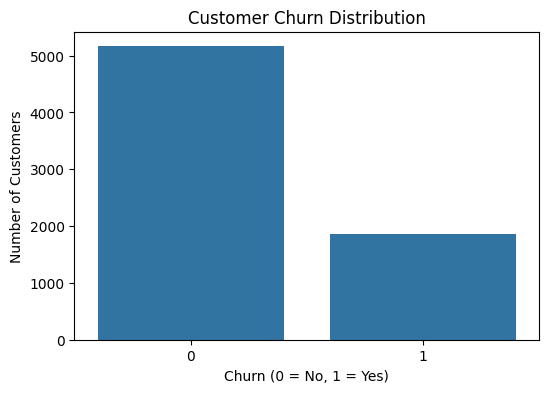


Churn Percentage:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


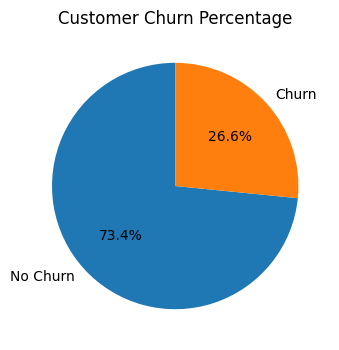

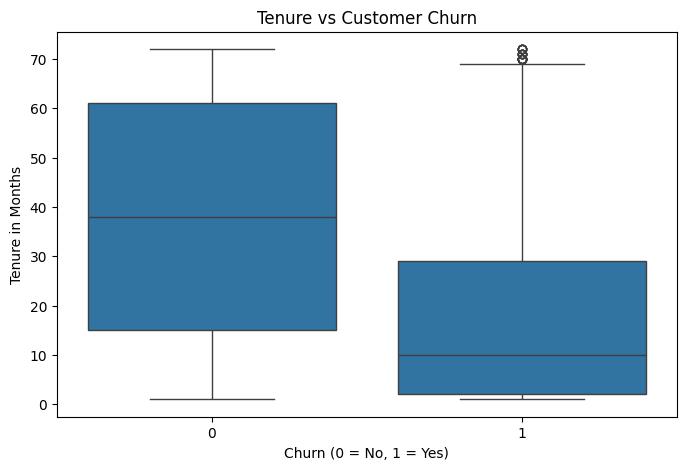

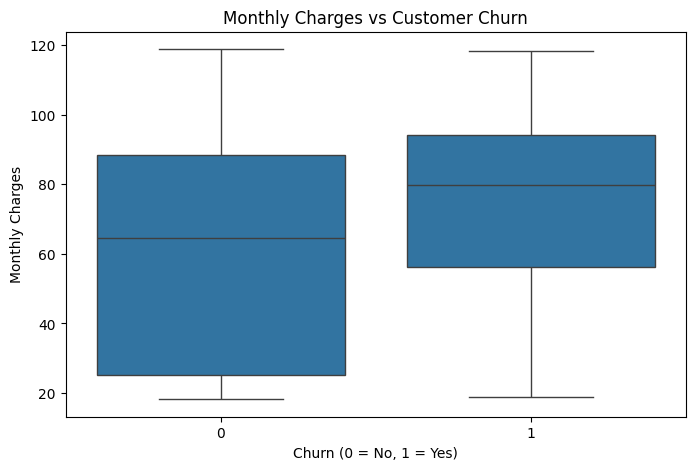

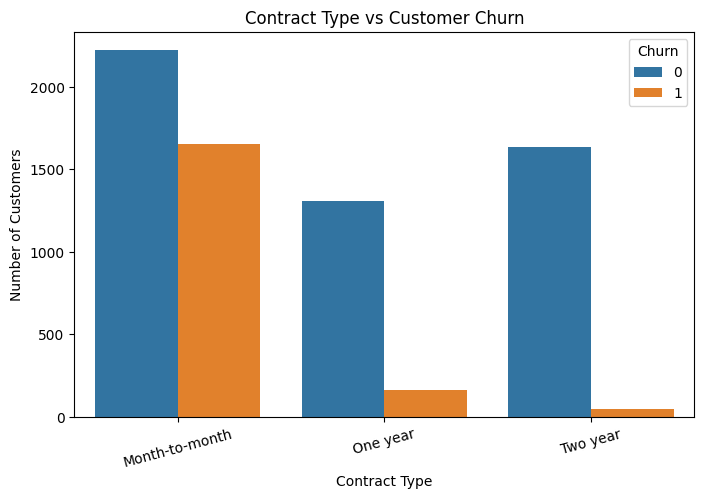

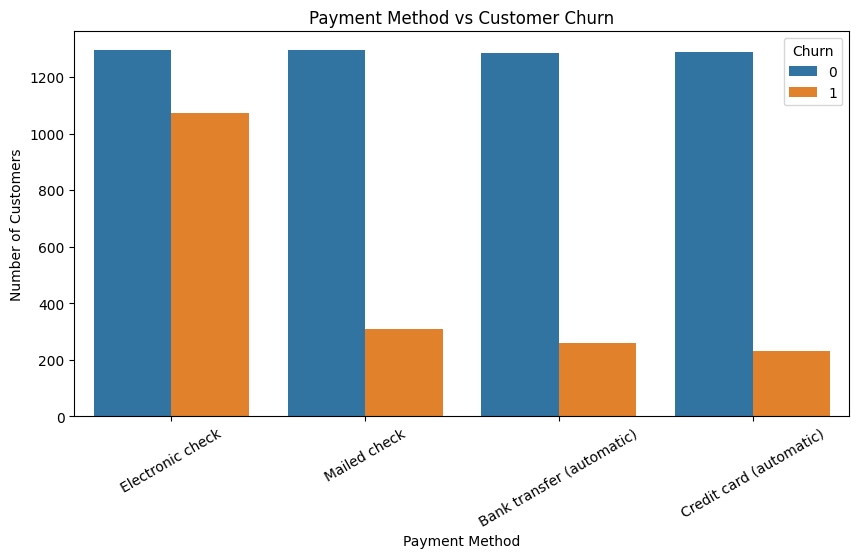

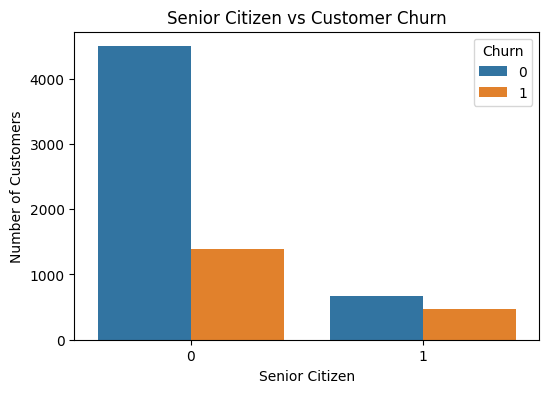


Encoded Dataset Shape: (7032, 30)

Training Data: (5625, 30)
Testing Data: (1407, 30)

LOGISTIC REGRESSION
Accuracy: 0.8038
Recall: 0.5749
ROC-AUC: 0.8357

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


RANDOM FOREST
Accuracy: 0.7896
Recall: 0.5187
ROC-AUC: 0.8165

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


XGBOOST
Accuracy: 0.7875
Recall: 0.5294
ROC-AUC: 0.8323

Classification Report

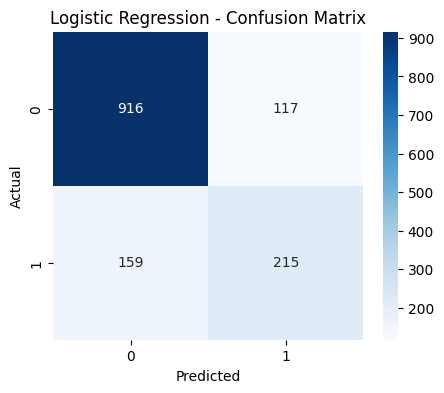

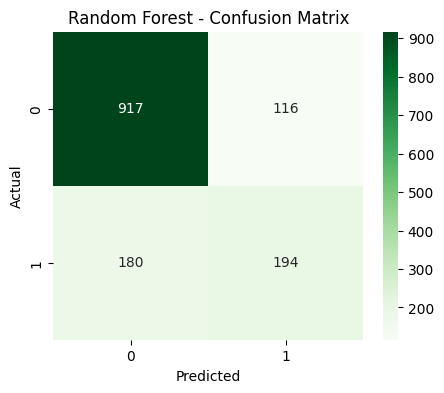

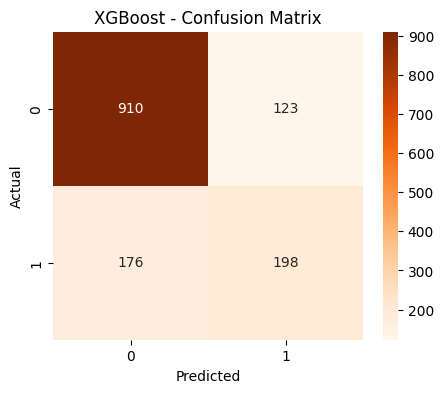

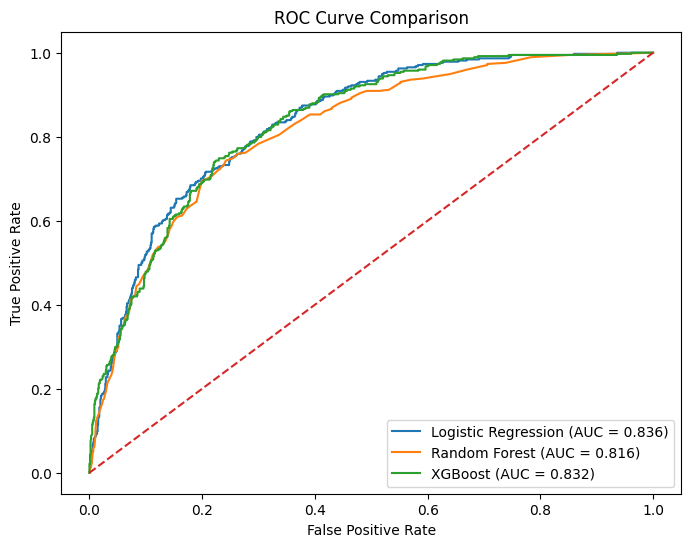


MODEL COMPARISON
                 Model  Accuracy  Recall  ROC-AUC
0  Logistic Regression    0.8038  0.5749   0.8357
1        Random Forest    0.7896  0.5187   0.8165
2              XGBoost    0.7875  0.5294   0.8323


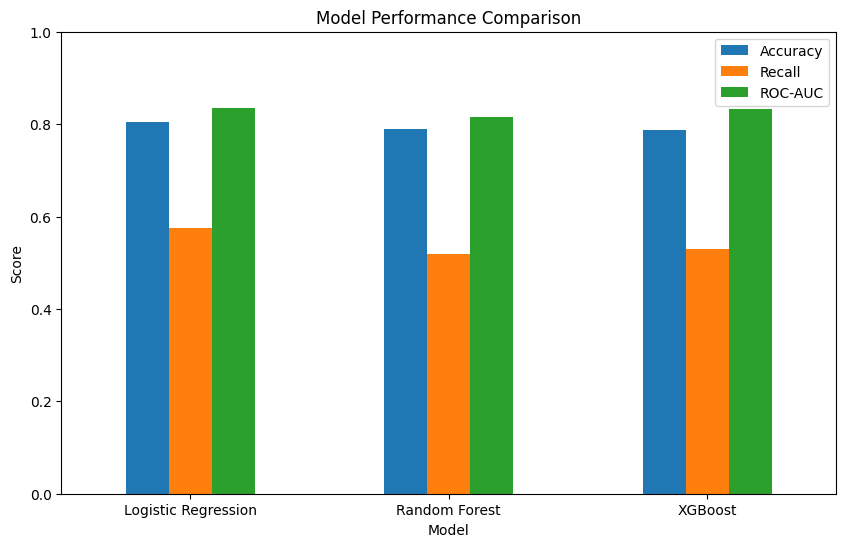


Top 15 Random Forest Features:
                           Feature  Importance
3                     TotalCharges    0.191435
1                           tenure    0.171020
2                   MonthlyCharges    0.168400
10     InternetService_Fiber optic    0.039481
28  PaymentMethod_Electronic check    0.037416
25               Contract_Two year    0.030529
4                      gender_Male    0.029332
13              OnlineSecurity_Yes    0.028157
26            PaperlessBilling_Yes    0.025536
19                 TechSupport_Yes    0.024114
5                      Partner_Yes    0.023682
15                OnlineBackup_Yes    0.022932
24               Contract_One year    0.022836
0                    SeniorCitizen    0.021035
6                   Dependents_Yes    0.019846


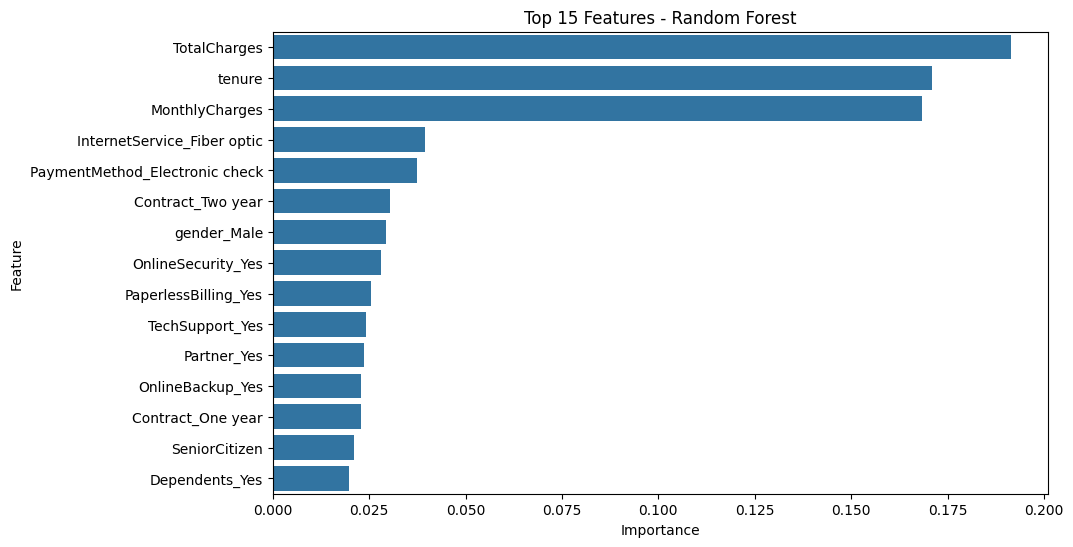


Top 15 XGBoost Features:
                               Feature  Importance
10         InternetService_Fiber optic    0.179854
11                  InternetService_No    0.141023
25                   Contract_Two year    0.139579
12  OnlineSecurity_No internet service    0.086494
24                   Contract_One year    0.060481
28      PaymentMethod_Electronic check    0.060188
1                               tenure    0.041430
8       MultipleLines_No phone service    0.030500
13                  OnlineSecurity_Yes    0.028787
23                 StreamingMovies_Yes    0.024984
9                    MultipleLines_Yes    0.019772
21                     StreamingTV_Yes    0.019616
19                     TechSupport_Yes    0.019480
26                PaperlessBilling_Yes    0.019294
3                         TotalCharges    0.019233


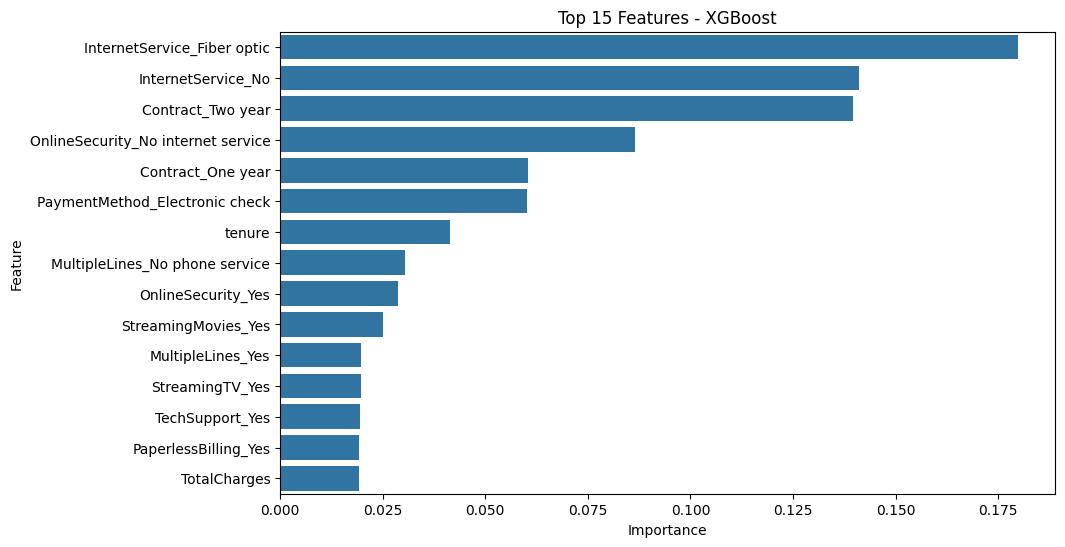


FINAL PROJECT SUMMARY
Dataset Shape: (7032, 20)

Logistic Regression
Accuracy: 0.8038
Recall: 0.5749
ROC-AUC: 0.8357

Random Forest
Accuracy: 0.7896
Recall: 0.5187
ROC-AUC: 0.8165

XGBoost
Accuracy: 0.7875
Recall: 0.5294
ROC-AUC: 0.8323

Customer Churn Prediction completed successfully!


In [2]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("\nMissing Values After Cleaning TotalCharges:")
print(df.isnull().sum())

df = df.dropna()

df = df.drop("customerID", axis=1)

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("\nChurn Percentage:")
print(churn_percentage)

plt.figure(figsize=(6, 4))
plt.pie(
    churn_percentage,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Churn Percentage")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)
plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure in Months")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)
plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)
plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)
plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)
plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

X = df.drop("Churn", axis=1)
y = df["Churn"]

X = pd.get_dummies(
    X,
    drop_first=True
)

X = X.astype(float)

print("\nEncoded Dataset Shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

logistic_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_recall = recall_score(
    y_test,
    logistic_pred
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_prob
)

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

print("Accuracy:", round(logistic_accuracy, 4))
print("Recall:", round(logistic_recall, 4))
print("ROC-AUC:", round(logistic_roc_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_pred
    )
)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

rf_pred = random_forest.predict(
    X_test
)

rf_prob = random_forest.predict_proba(
    X_test
)[:, 1]

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

print("Accuracy:", round(rf_accuracy, 4))
print("Recall:", round(rf_recall, 4))
print("ROC-AUC:", round(rf_roc_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob
)

print("\n==============================")
print("XGBOOST")
print("==============================")

print("Accuracy:", round(xgb_accuracy, 4))
print("Recall:", round(xgb_recall, 4))
print("ROC-AUC:", round(xgb_roc_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        xgb_recall
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(
    results.round(4)
)

results.set_index("Model")[
    ["Accuracy", "Recall", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

rf_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Random Forest Features:")
print(
    rf_feature_importance.head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

xgb_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 XGBoost Features:")
print(
    xgb_feature_importance.head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("\n==============================")
print("FINAL PROJECT SUMMARY")
print("==============================")

print("Dataset Shape:", df.shape)

print("\nLogistic Regression")
print("Accuracy:", round(logistic_accuracy, 4))
print("Recall:", round(logistic_recall, 4))
print("ROC-AUC:", round(logistic_roc_auc, 4))

print("\nRandom Forest")
print("Accuracy:", round(rf_accuracy, 4))
print("Recall:", round(rf_recall, 4))
print("ROC-AUC:", round(rf_roc_auc, 4))

print("\nXGBoost")
print("Accuracy:", round(xgb_accuracy, 4))
print("Recall:", round(xgb_recall, 4))
print("ROC-AUC:", round(xgb_roc_auc, 4))

print("\nCustomer Churn Prediction completed successfully!")